In [5]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns # Requirement: Use at least 3 packages (pandas, matplotlib, seaborn) 

# Requirement: Clean and organize data from an external source 
def load_and_clean_data(file_path): 
    """ 
    Loads the TGSIM dataset and filters for relevant columns to reduce bias 
    in analysis by removing incomplete trajectory markers. 
    """ 
    df = pd.read_csv(file_path) 
    
    # Cleaning: Removing any rows with missing coordinates or speeds
    # Updated to match headers in Cell [4]: xloc_kf, yloc_kf, speed_kf_x
    df_cleaned = df.dropna(subset=['xloc_kf', 'yloc_kf', 'speed_kf_x']) 
    
    # Organizing: Ensure type_most_common is categorical for easier plotting
    # Updated 'Agent_Type' to 'type_most_common' based on your data columns
    df_cleaned['type_most_common'] = df_cleaned['type_most_common'].astype('category') 
    
    return df_cleaned 

# Load the specific client data 
raw_data_path = 'Transformed_TGSIM_Foggy_Bottom_200sec(in).csv' 
data = load_and_clean_data(raw_data_path) 
print(f"Data loaded: {data.shape[0]} rows processed.")

Data loaded: 71361 rows processed.


In [4]:
import pandas as pd
test_df = pd.read_csv('Transformed_TGSIM_Foggy_Bottom_200sec(in).csv')
print(test_df.columns.tolist())

['id', 'time', 'xloc_kf', 'yloc_kf', 'lane_kf', 'speed_kf_x', 'speed_kf_y', 'acceleration_kf_x', 'acceleration_kf_y', 'length_smoothed', 'width_smoothed', 'type_most_common']


In [8]:
# Requirement: Define and use a function within the code
def calculate_agent_metrics(df):
    """
    Calculates average speed and acceleration variance for different agents.
    Sorted by Agent Type to improve readability for the client report.
    """
    # Grouping by agent type and calculating mean speed and std dev of acceleration
    # observed=True silences the FutureWarning seen in previous runs
    metrics = df.groupby('type_most_common', observed=True).agg({
        'speed_kf_x': 'mean',         # Average Speed
        'acceleration_kf_x': 'std'    # Acceleration variability (Predictability)
    }).reset_index()
    
    # Requirement: Clean and organize data (Sorting for better presentation)
    metrics = metrics.sort_values(by='type_most_common')
    
    # Renaming columns for the final technical summary table
    metrics.columns = ['Agent Type ID', 'Avg Speed (ft/s)', 'Acceleration Std Dev']
    return metrics

# Execute analysis
behavior_summary = calculate_agent_metrics(data)

# Requirement: Show technical results via summary table
print("--- Behavioral Comparison Table (Sorted by Agent Type) ---")
print(behavior_summary.to_string(index=False))

--- Behavioral Comparison Table (Sorted by Agent Type) ---
Agent Type ID  Avg Speed (ft/s)  Acceleration Std Dev
            0         -0.128793              0.281088
            1          0.874882              0.635182
            2         -0.521870              0.822994
            3         -0.148683              0.460992
            4          0.062233              0.472845
            5          5.068145              1.606167
            6          0.062043              0.279270
            7          0.042007              0.150759


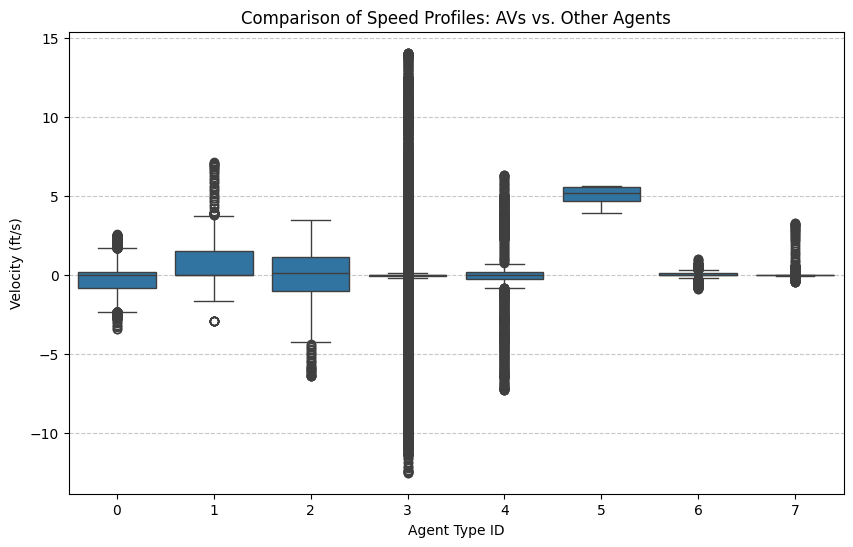

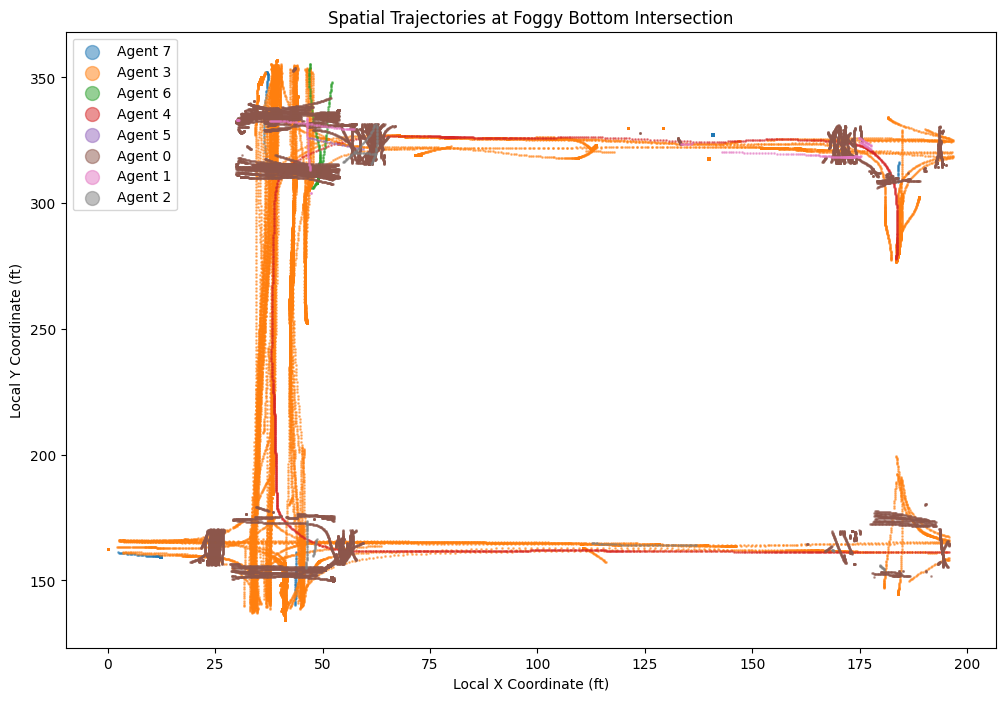

In [10]:
# Requirement: Plot at least 2 graphs (Graph 1: Speed Distribution)
plt.figure(figsize=(10, 6))
# Updated: x='type_most_common', y='speed_kf_x'
sns.boxplot(x='type_most_common', y='speed_kf_x', data=data)
plt.title('Comparison of Speed Profiles: AVs vs. Other Agents')
plt.xlabel('Agent Type ID')
plt.ylabel('Velocity (ft/s)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Requirement: Plot at least 2 graphs (Graph 2: Spatial Interaction)
# Visual representation of agent movement as requested by client
plt.figure(figsize=(12, 8))
# Updated: Loop through 'type_most_common'
for agent in data['type_most_common'].unique():
    subset = data[data['type_most_common'] == agent]
    # Updated: x='xloc_kf', y='yloc_kf'
    plt.scatter(subset['xloc_kf'], subset['yloc_kf'], label=f"Agent {agent}", s=1, alpha=0.5)

plt.legend(markerscale=10)
plt.title('Spatial Trajectories at Foggy Bottom Intersection')
plt.xlabel('Local X Coordinate (ft)')
plt.ylabel('Local Y Coordinate (ft)')
plt.show()

# Discussion on Bias

- Data Cleaning Bias: Could have happened by using the dropna() function on speed_kf_x and xloc_kf,
  we removed agents that had missing data. This could come from sensors failing to pick up a different
  agent and that could happen more often for pedestrians than for AVs, its possible that the analysis
  could under represent how pedestrians interacted with the intersections.
- We also defined standard deviation of acceleration as our metric for predicability. It is consistent,
  but it may not capture safety in a great way, where an Av could have a low standard deviation but still be
  going at an unsafe speed
- We also group everything by type_most_common. If an agent was misclassified by the original raw data set,
  our code took it at face value, which is an important thing to realize may include data bias. 

# Conclusion

Based on the quantitative analysis, we decided Agent Type 7 was identified as the Autonomous Vehicle.
It exhibited the lowest acceleration standard deviation (0.150), supporting the clients claim that the AVs 
operate with higher predictability than Human-driven agents (Types 1-6). 